In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/ds_salaries_cleaned.csv")

df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [3]:
df.shape

(565, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 565 entries, 0 to 564
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           565 non-null    int64 
 1   experience_level    565 non-null    object
 2   employment_type     565 non-null    object
 3   job_title           565 non-null    object
 4   salary              565 non-null    int64 
 5   salary_currency     565 non-null    object
 6   salary_in_usd       565 non-null    int64 
 7   employee_residence  565 non-null    object
 8   remote_ratio        565 non-null    int64 
 9   company_location    565 non-null    object
 10  company_size        565 non-null    object
dtypes: int64(4), object(7)
memory usage: 48.7+ KB


In [5]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,565.000000,5.650000e+02,565.000000,565.000000
mean,2021.364602,3.381160e+05,110610.343363,69.911504
std,0.698138,1.599879e+06,72280.702792,40.900666
min,2020.000000,4.000000e+03,2859.000000,0.000000
25%,2021.000000,6.700000e+04,60757.000000,50.000000
50%,2021.000000,1.109250e+05,100000.000000,100.000000
75%,2022.000000,1.650000e+05,150000.000000,100.000000
max,2022.000000,3.040000e+07,600000.000000,100.000000


In [6]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [7]:
df.nunique()

,0
work_year,3
experience_level,4
employment_type,4
job_title,50
salary,272
salary_currency,17
salary_in_usd,369
employee_residence,57
remote_ratio,3
company_location,50


In [8]:
df.nunique()

,0
work_year,3
experience_level,4
employment_type,4
job_title,50
salary,272
salary_currency,17
salary_in_usd,369
employee_residence,57
remote_ratio,3
company_location,50


In [9]:
df.isnull().sum()

,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary,0
salary_currency,0
salary_in_usd,0
employee_residence,0
remote_ratio,0
company_location,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.dtypes

,0
work_year,int64
experience_level,object
employment_type,object
job_title,object
salary,int64
salary_currency,object
salary_in_usd,int64
employee_residence,object
remote_ratio,int64
company_location,object


In [12]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].unique())


experience_level:
['MI' 'SE' 'EN' 'EX']

employment_type:
['FT' 'CT' 'PT' 'FL']

job_title:
['Data Scientist' 'Machine Learning Scientist' 'Big Data Engineer'
 'Product Data Analyst' 'Machine Learning Engineer' 'Data Analyst'
 'Lead Data Scientist' 'Business Data Analyst' 'Lead Data Engineer'
 'Lead Data Analyst' 'Data Engineer' 'Data Science Consultant'
 'BI Data Analyst' 'Director of Data Science' 'Research Scientist'
 'Machine Learning Manager' 'Data Engineering Manager'
 'Machine Learning Infrastructure Engineer' 'ML Engineer' 'AI Scientist'
 'Computer Vision Engineer' 'Principal Data Scientist'
 'Data Science Manager' 'Head of Data' '3D Computer Vision Researcher'
 'Data Analytics Engineer' 'Applied Data Scientist'
 'Marketing Data Analyst' 'Cloud Data Engineer' 'Financial Data Analyst'
 'Computer Vision Software Engineer' 'Director of Data Engineering'
 'Data Science Engineer' 'Principal Data Engineer'
 'Machine Learning Developer' 'Applied Machine Learning Scientist'
 'Data Ana

In [13]:
df[["salary", "salary_in_usd"]].describe()

,salary,salary_in_usd
count,5.650000e+02,565.000000
mean,3.381160e+05,110610.343363
std,1.599879e+06,72280.702792
min,4.000000e+03,2859.000000
25%,6.700000e+04,60757.000000
50%,1.109250e+05,100000.000000
75%,1.650000e+05,150000.000000
max,3.040000e+07,600000.000000


In [14]:
df["salary_currency"].value_counts()

,count
salary_currency,
USD,359
EUR,93
GBP,43
INR,27
CAD,18
JPY,3
PLN,3
TRY,3
HUF,2


In [16]:
df["salary_in_usd"].describe()

,salary_in_usd
count,565.000000
mean,110610.343363
std,72280.702792
min,2859.000000
25%,60757.000000
50%,100000.000000
75%,150000.000000
max,600000.000000


In [17]:
Q1 = df["salary_in_usd"].quantile(0.25)
Q3 = df["salary_in_usd"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 60757.0
Q3: 150000.0
IQR: 89243.0
Lower Bound: -73107.5
Upper Bound: 283864.5


In [18]:
outliers = df[
    (df["salary_in_usd"] < lower_bound) |
    (df["salary_in_usd"] > upper_bound)
]

outliers.shape

(10, 11)

In [19]:
outlier_count = len(outliers)
outlier_percentage = (outlier_count / len(df)) * 100

print("Number of outliers:", outlier_count)
print("Percentage:", round(outlier_percentage, 2), "%")

Number of outliers: 10
Percentage: 1.77 %


In [20]:
outliers.sort_values(
    "salary_in_usd",
    ascending=False
)[[
    "work_year",
    "job_title",
    "experience_level",
    "salary_in_usd",
    "company_size",
    "company_location"
]].head(20)

,work_year,job_title,experience_level,salary_in_usd,company_size,company_location
251,2021,Principal Data Engineer,EX,600000,L,US
33,2020,Research Scientist,MI,450000,M,US
97,2021,Financial Data Analyst,MI,450000,L,US
157,2021,Applied Machine Learning Scientist,MI,423000,L,US
224,2021,Principal Data Scientist,EX,416000,S,US
63,2020,Data Scientist,SE,412000,L,US
502,2022,Data Analytics Lead,SE,405000,L,US
498,2022,Applied Data Scientist,SE,380000,L,US
25,2020,Director of Data Science,EX,325000,L,US
461,2022,Data Engineer,EX,324000,M,US


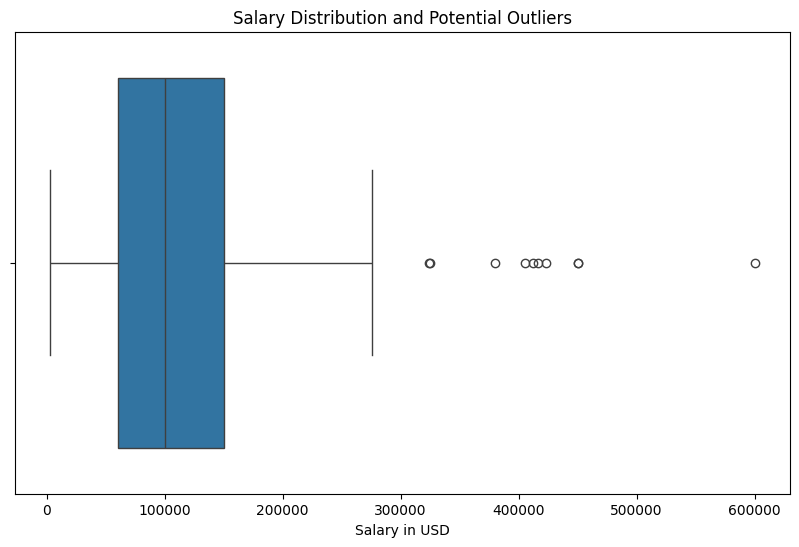

In [21]:
plt.figure(figsize=(10, 6))

sns.boxplot(x=df["salary_in_usd"])

plt.title("Salary Distribution and Potential Outliers")
plt.xlabel("Salary in USD")

plt.show()

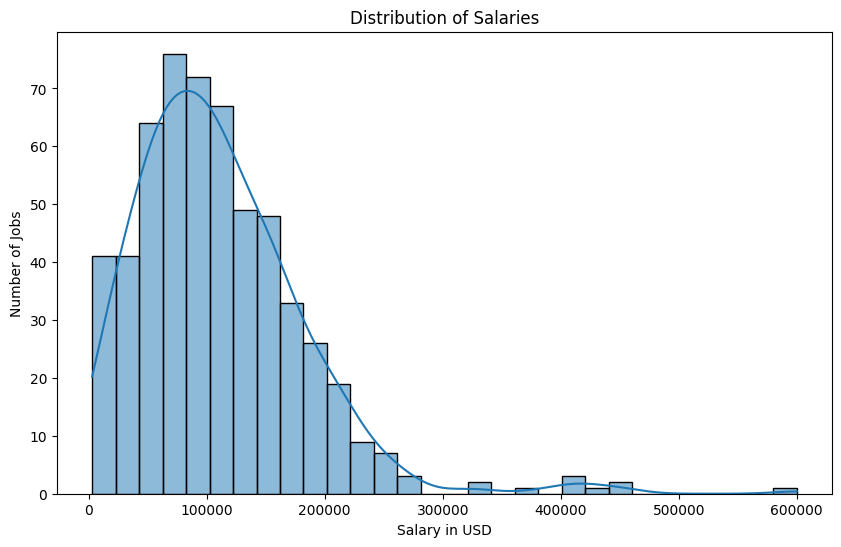

In [22]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["salary_in_usd"],
    bins=30,
    kde=True
)

plt.title("Distribution of Salaries")
plt.xlabel("Salary in USD")
plt.ylabel("Number of Jobs")

plt.show()

In [23]:
experience_salary = (
    df.groupby("experience_level")["salary_in_usd"]
      .agg(["count", "mean", "median"])
      .sort_values("mean", ascending=False)
)

experience_salary

,count,mean,median
experience_level,,,
EX,26,199392.038462,171437.5
SE,243,138374.880658,135000.0
MI,208,87792.995192,76940.0
EN,88,61643.318182,56500.0


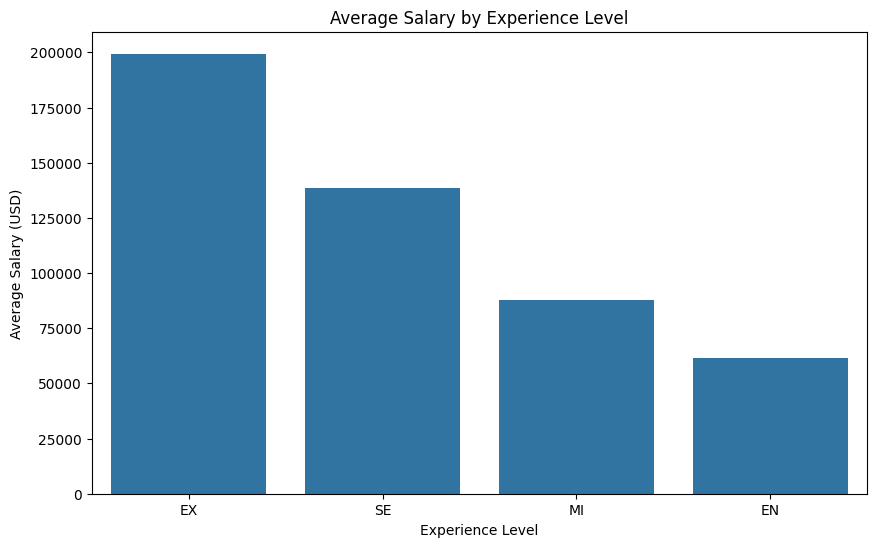

In [24]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=experience_salary.reset_index(),
    x="experience_level",
    y="mean"
)

plt.title("Average Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Average Salary (USD)")

plt.show()

In [25]:
company_salary = (
    df.groupby("company_size")["salary_in_usd"]
      .agg(["count", "mean", "median"])
      .sort_values("mean", ascending=False)
)

company_salary

,count,mean,median
company_size,,,
L,193,118213.880829,100000.0
M,290,114807.079310,109640.0
S,82,77872.097561,65511.0


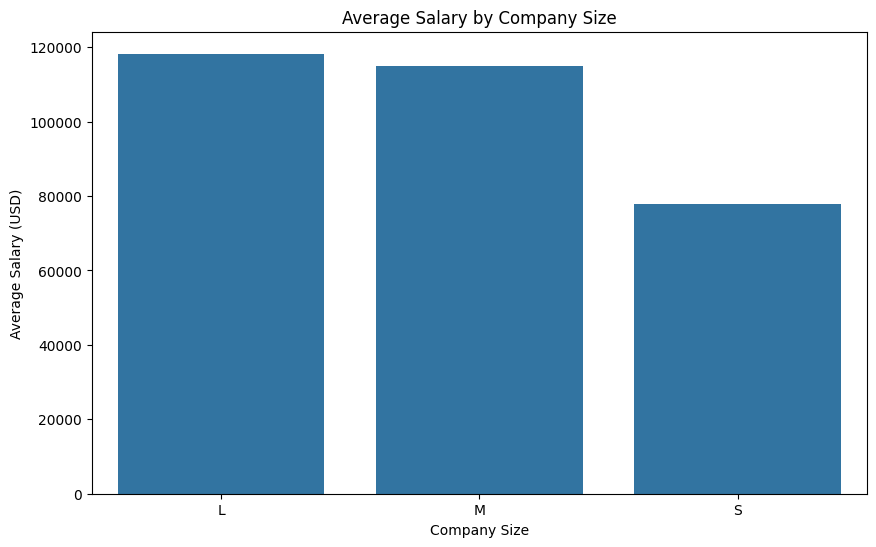

In [26]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=company_salary.reset_index(),
    x="company_size",
    y="mean"
)

plt.title("Average Salary by Company Size")
plt.xlabel("Company Size")
plt.ylabel("Average Salary (USD)")

plt.show()

In [27]:
year_salary = (
    df.groupby("work_year")["salary_in_usd"]
      .agg(["count", "mean", "median"])
      .sort_index()
)

year_salary

,count,mean,median
work_year,,,
2020,72,95813.000000,75544.0
2021,215,99430.413953,82528.0
2022,278,123089.097122,120000.0


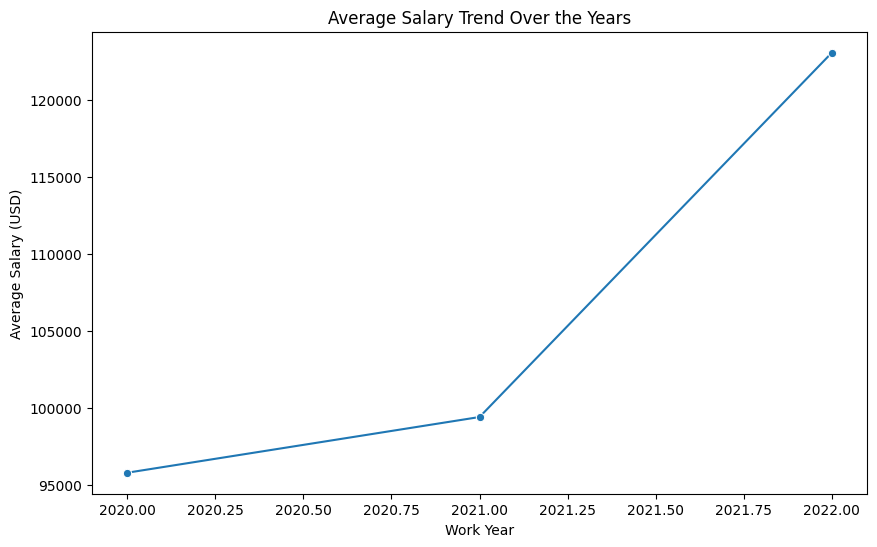

In [28]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=year_salary.reset_index(),
    x="work_year",
    y="mean",
    marker="o"
)

plt.title("Average Salary Trend Over the Years")
plt.xlabel("Work Year")
plt.ylabel("Average Salary (USD)")

plt.show()

In [29]:
title_salary = (
    df.groupby("job_title")["salary_in_usd"]
      .agg(["count", "mean", "median"])
      .sort_values("mean", ascending=False)
)

title_salary.head(20)

,count,mean,median
job_title,,,
Data Analytics Lead,1,405000.000000,405000.0
Principal Data Engineer,3,328333.333333,200000.0
Financial Data Analyst,2,275000.000000,275000.0
Principal Data Scientist,7,215242.428571,173762.0
Director of Data Science,7,195074.000000,168000.0
Data Architect,11,177873.909091,180000.0
Applied Data Scientist,5,175655.000000,157000.0
Analytics Engineer,4,175000.000000,179850.0
Data Specialist,1,165000.000000,165000.0


In [30]:
title_salary_filtered = (
    title_salary[
        title_salary["count"] >= 7
    ]
    .sort_values("mean", ascending=False)
)

title_salary_filtered.head(10)

,count,mean,median
job_title,,,
Principal Data Scientist,7,215242.428571,173762.0
Director of Data Science,7,195074.000000,168000.0
Data Architect,11,177873.909091,180000.0
Machine Learning Scientist,8,158412.500000,156500.0
Data Science Manager,12,158328.500000,155750.0
Data Analytics Manager,7,127134.285714,120000.0
Data Engineer,121,109750.033058,100800.0
Research Scientist,16,109019.500000,76263.5
Data Scientist,130,103336.353846,100000.0


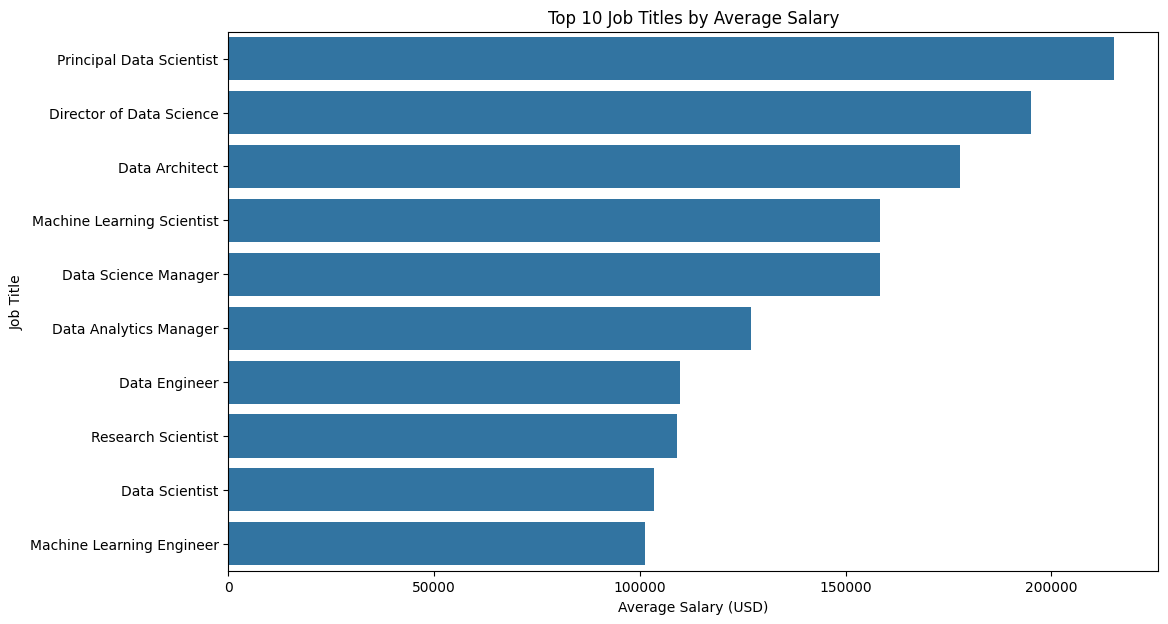

In [31]:
top_10_titles = title_salary_filtered.head(10)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_10_titles.reset_index(),
    x="mean",
    y="job_title"
)

plt.title("Top 10 Job Titles by Average Salary")
plt.xlabel("Average Salary (USD)")
plt.ylabel("Job Title")

plt.show()

In [32]:
location_salary = (
    df.groupby("company_location")["salary_in_usd"]
      .agg(["count", "mean", "median"])
      .sort_values("mean", ascending=False)
)

location_salary.head(20)

,count,mean,median
company_location,,,
RU,2,157500.000000,157500.0
US,318,144292.993711,135000.0
NZ,1,125000.000000,125000.0
IL,1,119059.000000,119059.0
JP,6,114127.333333,75682.0
AU,3,108042.666667,87425.0
CA,28,100121.857143,81895.5
DZ,1,100000.000000,100000.0
IQ,1,100000.000000,100000.0


In [33]:
location_salary_filtered = (
    location_salary[
        location_salary["count"] >= 7
    ]
    .sort_values("mean", ascending=False)
)

location_salary_filtered.head(20)

,count,mean,median
company_location,,,
US,318,144292.993711,135000.0
CA,28,100121.857143,81895.5
GB,46,81649.500000,78526.0
DE,27,81559.555556,76833.0
FR,15,63970.666667,56738.0
ES,14,53060.142857,48371.5
GR,10,52026.700000,48680.0
IN,24,28581.750000,22124.0


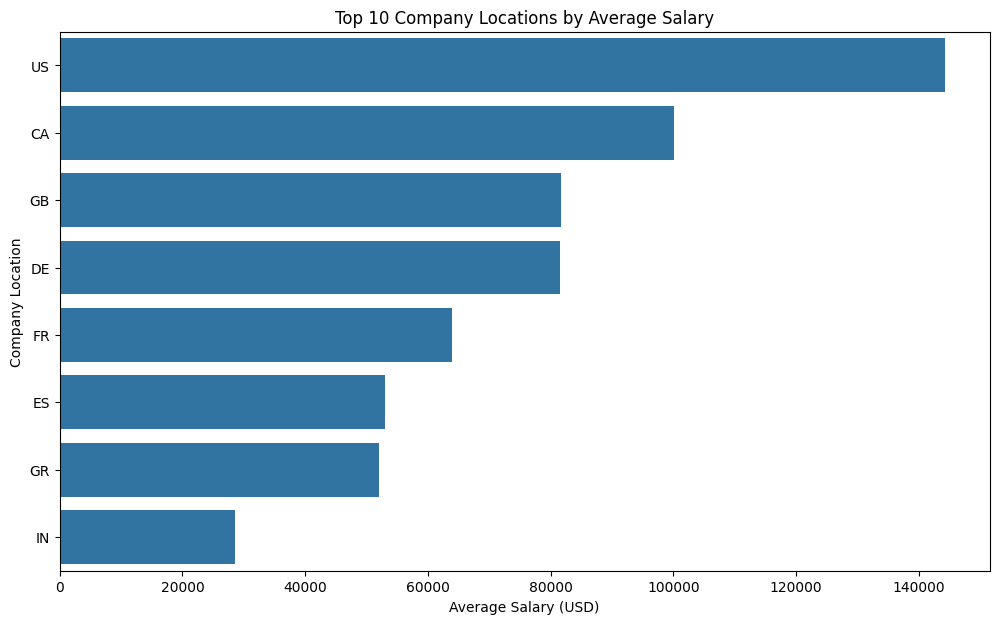

In [34]:
top_locations = location_salary_filtered.head(10)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_locations.reset_index(),
    x="mean",
    y="company_location"
)

plt.title("Top 10 Company Locations by Average Salary")
plt.xlabel("Average Salary (USD)")
plt.ylabel("Company Location")

plt.show()

In [35]:
employment_salary = (
    df.groupby("employment_type")["salary_in_usd"]
      .agg(["count", "mean", "median"])
      .sort_values("mean", ascending=False)
)

employment_salary

,count,mean,median
employment_type,,,
CT,5,184575.000000,105000.0
FT,546,111811.838828,100000.0
FL,4,48000.000000,40000.0
PT,10,33070.500000,18817.5


In [36]:
remote_salary = (
    df.groupby("remote_ratio")["salary_in_usd"]
      .agg(["count", "mean", "median"])
      .sort_values("mean", ascending=False)
)

remote_salary

,count,mean,median
remote_ratio,,,
100,346,120763.190751,110712.5
0,121,105785.404959,98158.0
50,98,80721.897959,68010.5


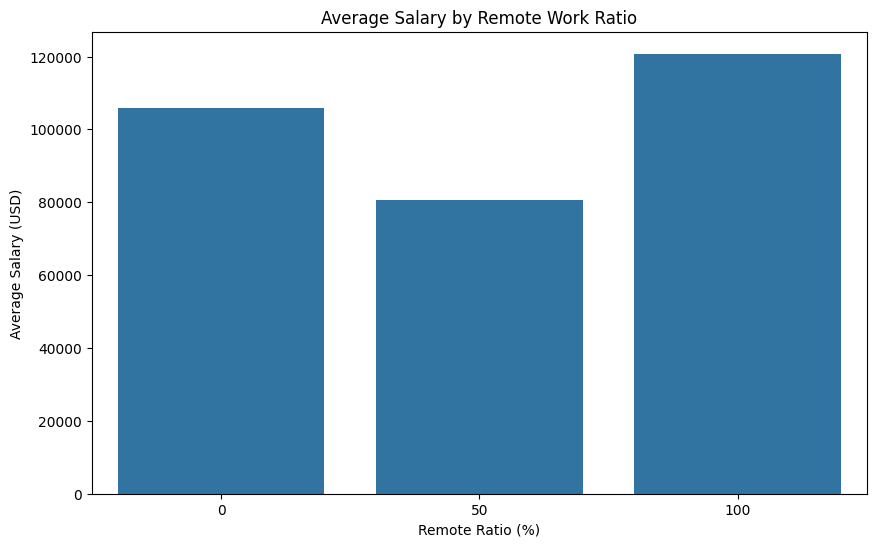

In [37]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=remote_salary.reset_index(),
    x="remote_ratio",
    y="mean"
)

plt.title("Average Salary by Remote Work Ratio")
plt.xlabel("Remote Ratio (%)")
plt.ylabel("Average Salary (USD)")

plt.show()

In [38]:
correlation = df[
    ["work_year", "salary_in_usd"]
].corr()

correlation

,work_year,salary_in_usd
work_year,1.000000,0.159326
salary_in_usd,0.159326,1.000000


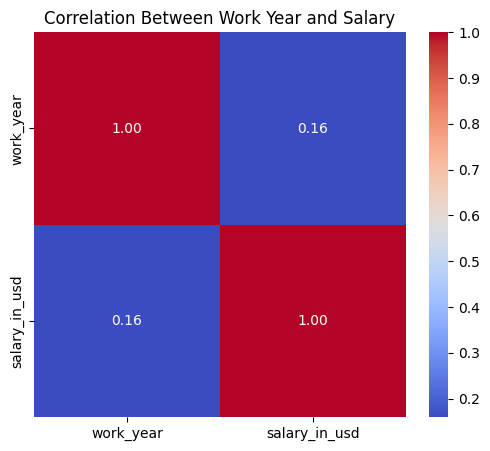

In [39]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Work Year and Salary")

plt.show()

In [40]:
print("Final Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Final Shape: (565, 11)

Missing Values:
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

Duplicate Rows:
0
